# Structuration de la Taxonomie des Tags Steam

## Objectif
Transformer la folksonomie brute de Steam (tags fournis par les utilisateurs) en une base de données de tags de gameplay propre et structurée, en s'appuyant sur la bibliographie :
- **VGMS (Video Game Metadata Schema)** : pour les entités et dimensions de classification.
- **Full Steam Ahead** (Windleharth et al.) : pour la correspondance spécifique entre les tags Steam et les catégories VGMS.

## Démarche
1. **Chargement des données** : Extraction des jeux et de leurs tags depuis la base SQLite.
2. **Définition de la Taxonomie** : Création d'un dictionnaire de correspondance classant les tags Steam dans des dimensions claires (Genre, Mécanique, Thème, etc.).
3. **Nettoyage et Filtrage** : Suppression des tags non informatifs (ex: 'Indie', 'Early Access') pour se concentrer sur le gameplay.
4. **Restructuration** : Création d'un nouveau dataset où chaque jeu est décrit par ses attributs dans chaque dimension.
5. **Analyse de la nouvelle base** : Visualisation de la répartition des jeux selon la nouvelle taxonomie.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db_path = '../data/2024-12-13.steam.db'
conn = sqlite3.connect(db_path)

query = """
SELECT 
    g.id as game_id,
    g.name as game_name,
    g.date as game_release_date,
    t.label as tag_label,
    gt.pos as tag_rank
FROM game_tag gt
JOIN games g ON gt.game_id = g.id
JOIN tags t ON gt.tag_id = t.id
"""
df = pd.read_sql_query(query, conn)
conn.close()

print(f"Associations chargées : {len(df)}")
df.head()

Associations chargées : 1491503


,game_id,game_name,game_release_date,tag_label,tag_rank
0,106127,The Platform,000000,Action,0
1,106127,The Platform,000000,Casual,1
2,106127,The Platform,000000,Simulation,2
3,106127,The Platform,000000,2D Fighter,3
4,106127,The Platform,000000,3D Fighter,4


*L'on constate que nous avons une grande quantité d'associations entre jeux et tags (1 491 503 associations), mais que ces tags sont très hétérogènes. Certains sont très génériques (ex: 'Indie', 'Early Access') tandis que d'autres sont plus spécifiques au gameplay (ex: 'Roguelike', 'Crafting'). Notre objectif est de filtrer ces tags pour ne garder que ceux qui apportent une information pertinente sur le gameplay et l'expérience de jeu, en les classant dans des dimensions claires.*

## Définition de la Taxonomie

Nous définissons ici les dimensions basées sur le VGMS et l'analyse de Windleharth et al. Nous utilisons une liste exhaustive de tags pour maximiser la couverture.


## Définitions Ludologiques Clés (selon la littérature académique)

### Termes Fondamentaux
- **Gameplay** : L'ensemble des mécaniques, des règles et des interactions qui constituent l'expérience interactive du joueur (Swink, 2009 ; Schell, 2019).
- **Genre** : Classification thématique ou ludique d'un jeu (ex: Action, RPG, Puzzle) basée sur des conventions narratives ou mécaniques récurrentes.
- **Mechanics** (Mécaniques) : Les règles, systèmes et interactions que le joueur contrôle directement pour progresser dans le jeu (Schell, 2019).
- **Theme** (Thème) : Le contexte narratif ou contextuel du jeu (ex: science-fiction, fantasy, histoire).
- **Setting** (Univers) : Le cadre spatial et temporel dans lequel se déroule le jeu.
- **Mood** (Ambiance) : L'atmosphère émotionnelle transmise par le jeu (ex: horrifique, épique, apaisant).
- **Aesthetics** (Esthétique) : Les éléments visuels, sonores et sensoriels qui composent l'expérience du joueur.
- **Perspective** : Le point de vue d'où le joueur observe et agit dans le monde du jeu (1ère personne, 3ème personne, isométrique, etc.).
- **Players** (Nombre de joueurs) : Dimension sociale du gameplay (solo, multijoueur coopératif, compétitif).

In [3]:
taxonomy = {
    "Genre": [
        "Strategy", "Tower Defense", "City Builder", "Sandbox", "Roguelike", "Roguelite", "Traditional Roguelike",
        "Survival", "Tactical", "Management", "Platformer", "Action", "2D Platformer", "Adventure", "Casual",
        "Interactive Fiction", "Point & Click", "Puzzle", "Simulation", "Visual Novel", "Dating Sim",
        "Character Action Game", "Immersive Sim", "Turn-Based Strategy", "Life Sim", "Music", "Creature Collector",
        "Racing", "Flight", "Runner", "RPG", "Party-Based RPG", "Turn-Based", "2D Fighter", "3D Fighter",
        "Action RPG", "3D Platformer", "God Game", "RTS", "Real Time Tactics", "CRPG", "Walking Simulator",
        "Metroidvania", "Survival Horror", "JRPG", "Card Battler", "Deckbuilding", "Card Game", "Roguelike Deckbuilder",
        "Action-Adventure", "MMORPG", "Choose Your Own Adventure", "FPS", "Third-Person Shooter", "Shooter",
        "Space Sim", "Beat 'em up", "Hack and Slash", "Turn-Based Tactics", "Tactical RPG", "Battle Royale",
        "Arena Shooter", "Bullet Hell", "Hero Shooter", "Shoot 'Em Up", "Top-Down Shooter", "Action Roguelike",
        "Puzzle Platformer", "Rhythm", "Strategy RPG", "Otome", "Auto Battler", "Trading Card Game", "Word Game",
        "Automobile Sim", "Match 3", "4X", "Grand Strategy", "Action RTS", "Board Game", "Wargame", "MOBA",
        "Fighting", "Twin Stick Shooter", "Mystery Dungeon", "eSports", "Farming Sim", "Political Sim", "Solitaire",
        "Trivia", "Colony Sim", "Medical Sim", "Boomer Shooter", "Extraction Shooter", "Boss Rush", "Social Deduction",
        "Job Simulator", "Outbreak Sim", "Musou", "Hobby Sim"
    ],
    "Mechanics": [
        "Procedural Generation", "Grid-Based Movement", "Base Building", "Building", "Level Editor",
        "Character Customization", "Investigation", "Collectathon", "Idler", "Physics", "Crafting",
        "Controller", "Open World", "Resource Management", "Clicker", "Inventory Management", "Choices Matter",
        "Artificial Intelligence", "Multiple Endings", "Gun Customization", "Music-Based Procedural Generation",
        "Turn-Based Combat", "Logic", "Automation", "Hacking", "Economy", "Diplomacy", "6DOF", "Sokoban",
        "Time Management", "Vehicular Combat", "Loot", "Mining", "Destruction", "Mechs", "Score Attack",
        "Escape Room", "Stealth", "Bullet Time", "Time Travel", "Mouse only", "On-Rails Shooter", "Lemmings",
        "Parkour", "Hunting", "Open World Survival Craft", "Dynamic Narration", "Minigames", "Quick-Time Events",
        "Addictive", "Time Manipulation", "Real-Time", "Real-Time with Pause", "Social Deduction", "Dice",
        "Intentionally Awkward Controls", "Tile-Matching", "Jump Scare"
    ],
    "Theme": [
        "Fantasy", "LEGO", "Futuristic", "Cyberpunk", "Supernatural", "Detective", "Mystery", "Sexual Content",
        "Nudity", "Mature", "NSFW", "Hentai", "Romance", "Anime", "Family Friendly", "Nature", "Zombies",
        "Medieval", "Tabletop", "Sci-fi", "Post-apocalyptic", "War", "Historical", "Demons", "Psychedelic",
        "Werewolves", "Gothic", "Vampire", "Cats", "Aliens", "Drama", "Emotional", "Dark Fantasy", "Combat",
        "Swordplay", "Robots", "LGBTQ", "Magic", "Underground", "Dystopian", "Dragons", "Education", "Programming",
        "Steampunk", "Mythology", "Science", "Dark Humor", "Superhero", "America", "Memes", "Parody",
        "Philosophical", "Lovecraftian", "Pirates", "Capitalism", "Faith", "Blood", "Classic", "Ninja", "Assassin",
        "Noir", "Abstract", "Dwarf", "Dinosaurs", "Conspiracy", "Illuminati", "Politics", "Comic Book", "Crime",
        "Villain Protagonist", "Satire", "Agriculture", "Nostalgia", "Medical", "Cold War", "Vikings", "Dog",
        "Farming", "Dungeons & Dragons", "Warhammer 40K", "Gambling", "Transhumanism", "Based On A Novel", "Fox"
    ],
    "Setting": [
        "Space", "Underwater", "Modern", "1980s", "1990's", "America", "Rome", "Mars", "Cold War"
    ],
    "Mood": [
        "Atmospheric", "Dark", "Psychological Horror", "Funny", "Relaxing", "Cozy", "Wholesome", "Ambient",
        "Gore", "Surreal", "Story Rich", "Psychedelic", "Psychological", "Difficult", "Stylized", "Emotional",
        "Lore-Rich", "Dark Humor", "Cinematic", "Dark Comedy", "Beautiful", "Short", "Unforgiving", "Experimental",
        "Addictive"
    ],
    "Aesthetics": [
        "Minimalist", "Pixel Graphics", "Colorful", "3D", "2D", "Cartoon", "Cartoony", "Stylized", "FMV",
        "Hand-drawn", "Old School", "3D Vision", "Voxel", "2.5D", "Abstract", "Retro", "8-bit Music", "Instrumental Music",
        "Rock Music", "Electronic Music"
    ],
    "Perspective": [
        "Isometric", "First-Person", "Third Person", "Side Scroller", "Top-Down"
    ],
    "Players": [
        "Singleplayer", "Multiplayer", "Online Co-Op", "PvE", "Massively Multiplayer", "Co-op", "PvP",
        "Co-op Campaign", "Team-Based", "Local Co-Op", "Local Multiplayer", "4 Player Local", "Split Screen",
        "Competitive", "Asynchronous Multiplayer"
    ]
}

# Inversion du dictionnaire pour un mapping rapide
tag_to_category = {}
for category, tags in taxonomy.items():
    for tag in tags:
        tag_to_category[tag] = category

## Nettoyage et Application de la Taxonomie

Nous filtrons les tags pour ne garder que ceux qui apportent une information sémantique sur le gameplay et l'expérience, en excluant les tags de distribution (Indie, Early Access, etc.).

In [4]:
# Filtrage des tags
df_clean = df[df['tag_label'].isin(tag_to_category.keys())].copy()

# Ajout de la catégorie
df_clean['category'] = df_clean['tag_label'].map(tag_to_category)

print(f"Nombre d'associations après filtrage : {len(df_clean)}")
df_clean.head()

Nombre d'associations après filtrage : 1224027


,game_id,game_name,game_release_date,tag_label,tag_rank,category
0,106127,The Platform,000000,Action,0,Genre
1,106127,The Platform,000000,Casual,1,Genre
2,106127,The Platform,000000,Simulation,2,Genre
3,106127,The Platform,000000,2D Fighter,3,Genre
4,106127,The Platform,000000,3D Fighter,4,Genre


*Après ce filtrage pour garder uniquement les tags pertinents pour la classification, nous avons réduit notre base à 1 224 027 associations. Nous allons maintenant restructurer ces données pour obtenir une base de données plus exploitable, avec un format "un jeu par ligne" et des colonnes pour chaque dimension de notre taxonomie.*

## Structuration de la base de données

Nous pivotons les données pour obtenir un format "un jeu par ligne" avec des colonnes par dimension VGMS.

In [5]:
# Groupement des tags par jeu et catégorie
game_structured = df_clean.groupby(['game_id', 'game_name', 'game_release_date', 'category'])['tag_label'].apply(lambda x: ', '.join(x)).unstack().reset_index()

# Sauvegarde du résultat
game_structured.to_csv('../data/Games_Gameplay_Taxonomy.csv', index=False)
print("Base de données structurée sauvegardée dans 'data/Games_Gameplay_Taxonomy.csv'")

game_structured.head()

Base de données structurée sauvegardée dans 'data/Games_Gameplay_Taxonomy.csv'


category,game_id,game_name,game_release_date,Aesthetics,Genre,Mechanics,Mood,Perspective,Players,Setting,Theme
0,1,"Cook, Serve, Delicious! 3?!",201014,2D,"Management, Casual, Strategy, Simulation, Action",NaN,"Difficult, Funny",NaN,"Co-op, Local Co-Op, Multiplayer, Local Multipl...",NaN,Family Friendly
1,2,Hellish Quart,210216,3D,"Fighting, 3D Fighter, Action","Character Customization, Physics",Cinematic,Third Person,"PvE, PvP, Local Multiplayer",NaN,"Swordplay, Historical, Medieval, Combat"
2,3,The ScreaMaze,190110,NaN,Puzzle,NaN,NaN,NaN,Singleplayer,NaN,NaN
3,4,Clam Man,190523,NaN,"Adventure, Point & Click",NaN,Funny,NaN,NaN,NaN,NaN
4,5,Fist Of Heaven & Hell,190628,NaN,"Action, Adventure",NaN,NaN,NaN,NaN,NaN,NaN


*Nous avons maintenant une base de données structurée où chaque ligne correspond à un jeu, avec des colonnes pour chaque dimension de notre taxonomie (Genre, Mécanique, Thème, etc.). Chaque colonne contient une liste de tags associés à cette dimension pour le jeu en question. Nous allons maintenant analyser la couverture de cette nouvelle taxonomie sur l'ensemble du catalogue.*

## Analyse de la Couverture

Vérifions si notre nouvelle taxonomie couvre bien l'ensemble du catalogue.

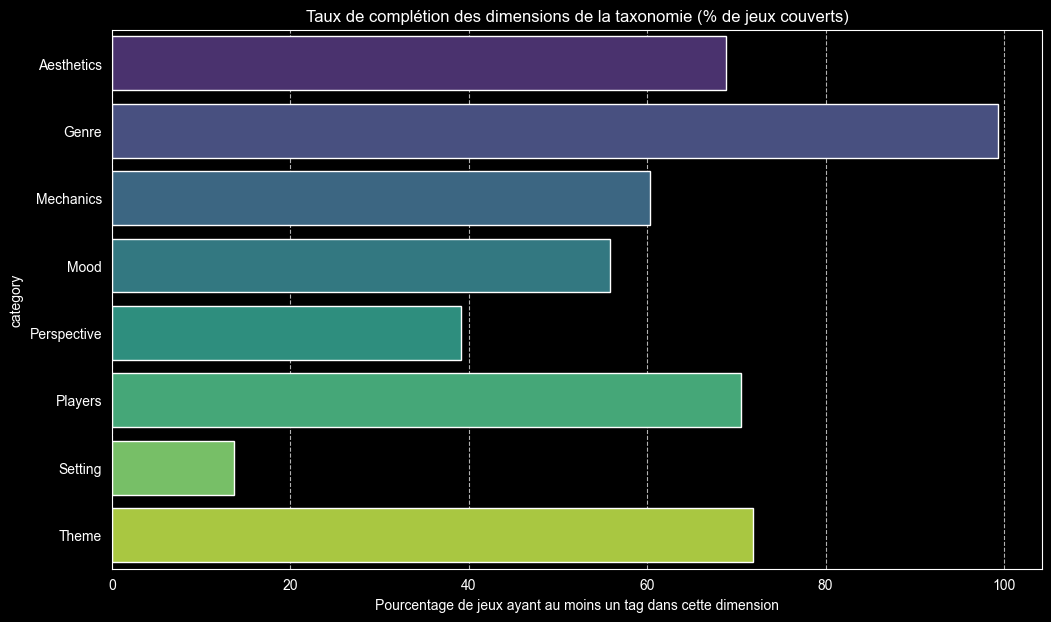

Nombre total de jeux dans la base structurée : 100384


In [6]:
completion = game_structured.drop(['game_id', 'game_name', 'game_release_date'], axis=1).notnull().mean() * 100

plt.figure(figsize=(12, 7))
sns.barplot(x=completion.values, y=completion.index, hue=completion.index, palette="viridis", legend=False)
plt.title("Taux de complétion des dimensions de la taxonomie (% de jeux couverts)")
plt.xlabel("Pourcentage de jeux ayant au moins un tag dans cette dimension")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"Nombre total de jeux dans la base structurée : {len(game_structured)}")

*Notre taxonomie couvre une grande partie du catalogue, avec des taux de complétion élevés pour les dimensions Genre, Mécanique et Thème. Cela nous donne une base solide pour les analyses futures, comme la détection de clusters de jeux similaires ou l'étude des corrélations entre les différentes dimensions.*

## Conclusion

Nous avons réussi à transformer la folksonomie brute de Steam en une base de données structurée et exploitable pour l'analyse de gameplay.

**Points clés :**
1.  **Nettoyage efficace** : Nous avons filtré le bruit (tags marketing, distribution) pour ne garder que l'essence du jeu.
2.  **Structure multidimensionnelle** : Chaque jeu est maintenant décrit selon des axes clairs (Genre, Mécanique, Thème, etc.), ce qui est beaucoup plus riche qu'une simple liste de tags à plat.
3.  **Couverture satisfaisante** : La majorité des jeux possèdent des informations sur leur genre et leurs mécaniques, ce qui valide la pertinence de notre taxonomie.

**Prochaines étapes :**
Cette base structurée (`Games_Gameplay_Taxonomy.csv`) servira de fondation pour :
- **L'analyse de réseau** : Voir comment les genres et les mécaniques interagissent.
- **Le clustering** : Identifier des familles de jeux basées sur des profils de gameplay similaires plutôt que sur des étiquettes marketing.
- **La comparaison Expert vs Foule** : Comparer cette classification issue de la foule avec des classifications expertes.
